# SKINTYPE MAPPING 

---


## Part 1 — Exploration

In [23]:
import pandas as pd
import ast
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

In [24]:
df = pd.read_csv("../data/processed/products_dataset_clean_tokens.csv")
df['ingredient_tokens_clean'] = df['ingredient_tokens_clean'].apply(ast.literal_eval)

all_ingredients = [ing.lower() for sublist in df['ingredient_tokens_clean'] for ing in sublist]
ingredient_counts = Counter(all_ingredients)

print(f"Total products: {len(df)}")
print(f"Total unique ingredients: {len(set(all_ingredients))}")
print(f"Total ingredient occurrences: {len(all_ingredients)}")

Total products: 50305
Total unique ingredients: 26139
Total ingredient occurrences: 1222868


### Ingredient frequency distribution

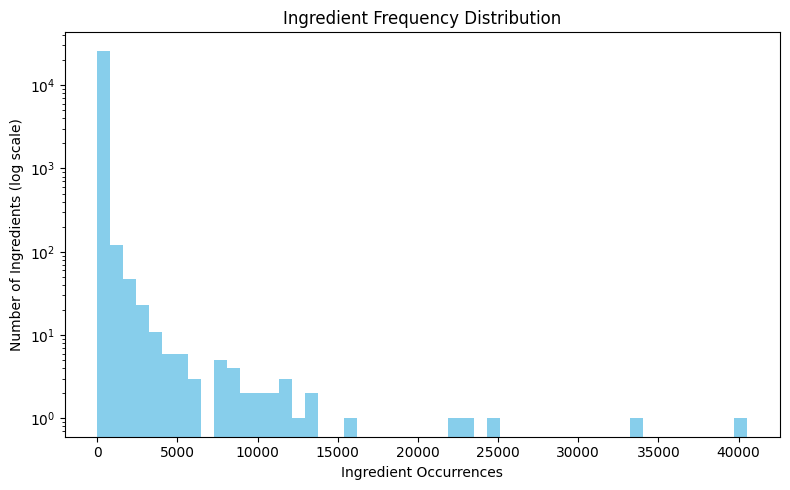

In [25]:
plt.figure(figsize=(8, 5))
plt.hist([c for _, c in ingredient_counts.items()], bins=50, log=True, color='skyblue')
plt.xlabel("Ingredient Occurrences")
plt.ylabel("Number of Ingredients (log scale)")
plt.title("Ingredient Frequency Distribution")
plt.tight_layout()
plt.show()

### High-frequency structural ingredients (≥8 000 occurrences)

These appear in nearly every product (solvents, humectants, preservatives). As noted, they carry little **discriminative** signal for skin-type matching since they are ubiquitous across all product types.

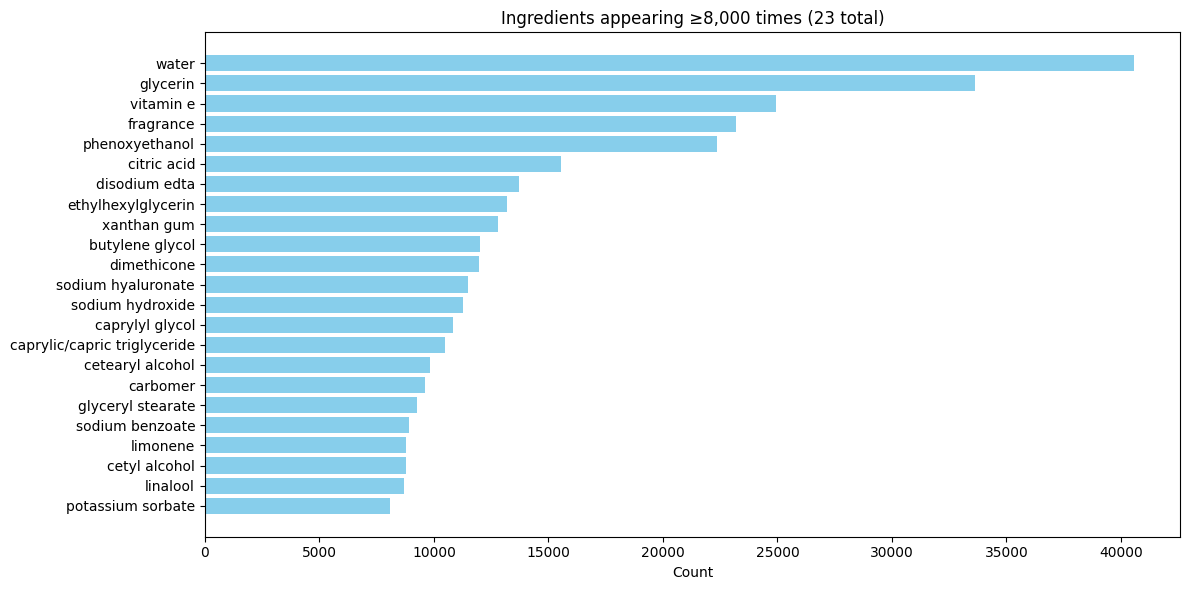

  water: 40,550
  glycerin: 33,628
  vitamin e: 24,934
  fragrance: 23,183
  phenoxyethanol: 22,375
  citric acid: 15,538
  disodium edta: 13,708
  ethylhexylglycerin: 13,200
  xanthan gum: 12,795
  butylene glycol: 12,030
  dimethicone: 11,982
  sodium hyaluronate: 11,497
  sodium hydroxide: 11,280
  caprylyl glycol: 10,837
  caprylic/capric triglyceride: 10,490
  cetearyl alcohol: 9,814
  carbomer: 9,624
  glyceryl stearate: 9,264
  sodium benzoate: 8,916
  limonene: 8,796
  cetyl alcohol: 8,773
  linalool: 8,680
  potassium sorbate: 8,075


In [26]:
threshold = 8000
important_ingredients = sorted(
    [(ing, cnt) for ing, cnt in ingredient_counts.items() if cnt >= threshold],
    key=lambda x: -x[1]
)

ingredients_hi = [ing for ing, _ in important_ingredients]
counts_hi      = [cnt for _, cnt in important_ingredients]

plt.figure(figsize=(12, 6))
plt.barh(ingredients_hi[::-1], counts_hi[::-1], color='skyblue')
plt.xlabel('Count')
plt.title(f'Ingredients appearing ≥{threshold:,} times ({len(important_ingredients)} total)')
plt.tight_layout()
plt.show()

for ing, cnt in important_ingredients:
    print(f"  {ing}: {cnt:,}")

### Mid-frequency ingredients — the discriminative signal carriers

Ingredients with 50–2,000 occurrences are frequent enough to be statistically meaningful but discriminative enough to carry skin-type signal. These are the ingredients that actually differ between product types.

In [27]:
mid_ingredients = sorted(
    [(ing, cnt) for ing, cnt in ingredient_counts.items() if 50 < cnt < 2000],
    key=lambda x: -x[1]
)

print("Top 50 mid-frequency ingredients:")
for ing, cnt in mid_ingredients[:50]:
    print(f"  {ing}: {cnt}")

Top 50 mid-frequency ingredients:
  sorbitol: 1987
  potassium hydroxide: 1979
  benzyl benzoate: 1970
  olea europaea (olive) fruit oil: 1969
  caffeine: 1968
  hyaluronic acid: 1940
  sodium pca: 1925
  maltodextrin: 1914
  cholesterol: 1912
  ethylhexyl palmitate: 1912
  polyquaternium-7: 1898
  alpha-isomethyl ionone: 1881
  glyceryl caprylate: 1877
  tetrasodium glutamate diacetate: 1874
  prunus amygdalus dulcis (sweet almond) oil: 1867
  sodium phytate: 1862
  mineral oil: 1858
  octyldodecanol: 1849
  methylisothiazolinone: 1846
  behenyl alcohol: 1842
  trehalose: 1816
  adenosine: 1799
  peg-40 hydrogenated castor oil: 1796
  dimethiconol: 1777
  hydroxyethyl acrylate/sodium acryloyldimethyl taurate copolymer: 1774
  cetearyl glucoside: 1758
  rosmarinus officinalis (rosemary) leaf extract: 1723
  persea gratissima (avocado) oil: 1715
  retinyl palmitate: 1693
  sorbitan olivate: 1681
  glycolic acid: 1662
  benzoic acid: 1657
  hydroxycitronellal: 1652
  sorbitan isostearate

---

## Part 2 — Building `COSING_DB` from the full EU CosIng export

In v2, `COSING_DB` was manually curated for only 50 ingredients, meaning 99.8% of ingredient signals were derived from name-embedding similarity — not real function data.

Here we replace it with the full EU CosIng Inventory (~28k entries). Every ingredient that exists in CosIng now gets its signal from real INCI function labels. Embedding propagation is reserved only for ingredients genuinely absent from the database.

In [ ]:
cosing_raw = pd.read_csv(
    "../data/external/COSING_Ingredients-Fragrance_Inventory_v2.csv",
    skiprows=9,
    encoding='latin1',
    on_bad_lines='skip'
)

# normalizing INCI names for consistent lookups
cosing_raw['inci_clean'] = cosing_raw['INCI name'].str.strip().str.lower()

COSING_DB = {
    row['inci_clean']: {
        'functions': [f.strip().lower() for f in str(row['Function']).split(',') if f.strip()]
    }
    for _, row in cosing_raw.iterrows()
    if pd.notna(row['Function'])
}

print(f"COSING_DB size: {len(COSING_DB):,} entries")

COSING_DB size: 28,487 entries


---

## Part 3 — Signal Propagation

Two tiers, same as v2 — but Tier A now covers the vast majority of ingredient occurrences:

| Tier | Trigger | Method | Trust |
|---|---|---|---|
| **A — Direct** | ingredient ∈ `COSING_DB` | INCI function → signal vector | Ground truth |
| **B — Propagation** | ingredient ∉ `COSING_DB` | Sentence-transformer cosine similarity → weighted average of top-K seed signals | Probabilistic |

**Confidence gate:** if max cosine similarity to any seed is below `MIN_SIM = 0.35`, the ingredient receives a zero vector rather than a low-confidence propagated signal.

In [29]:
import sys
sys.path.append("../scripts/../")
from scripts.cosing_mapper import cosing_to_vector

SIGNAL_KEYS = [
    "hydration", "barrier", "acne_control",
    "soothing", "exfoliation", "antioxidant", "irritation_risk"
]
ZERO_SIGNAL = {k: 0.0 for k in SIGNAL_KEYS}

TOP_K   = 5
MIN_SIM = 0.35

### Tier A coverage check

Before building the signal map, measure how much of the actual ingredient mass (occurrences, not unique count) is covered by Tier A. 

Disclaimer:
My first approach was matching the top 50 (mid-frequency) ingredients to their CosIng function in cosing_lookup.py that I manually extracted. Then, I realized that I could just get the actual db and just match ingredients to that, so that's what the following code does. My initial coverage was around 6% (with the top frequent ingredients) and around 9% (without the most frequent ingredients). So as expected, coverage increased drastically once i used teh db.

In [ ]:
all_unique = sorted({
    ing
    for tokens in df["ingredient_tokens_clean"]
    for ing in tokens
})

tier_a_ings = [ing for ing in all_unique if ing in COSING_DB]
tier_b_ings = [ing for ing in all_unique if ing not in COSING_DB]

total_occ   = sum(ingredient_counts.values())
tier_a_occ  = sum(ingredient_counts.get(ing, 0) for ing in tier_a_ings)
tier_a_pct  = tier_a_occ / total_occ * 100

print(f"Unique ingredients total : {len(all_unique):>7,}")
print(f"  Tier A (CosIng match)  : {len(tier_a_ings):>7,}  ({len(tier_a_ings)/len(all_unique)*100:.1f}% of unique)")
print(f"  Tier B (need embedding): {len(tier_b_ings):>7,}  ({len(tier_b_ings)/len(all_unique)*100:.1f}% of unique)")
print()
print(f"Tier A coverage by occurrence: {tier_a_pct:.1f}%")

if tier_a_pct < 30:
    print("\nCoverage still low — ingredient name normalisation may need work (see below)")
elif tier_a_pct < 50:
    print("\nAcceptable coverage — Tier B fills the remainder")
else:
    print("\nGood coverage — majority of ingredient mass has real CosIng signal")

Unique ingredients total :  26,139
  Tier A (CosIng match)  :   6,613  (25.3% of unique)
  Tier B (need embedding):  19,526  (74.7% of unique)

Tier A coverage by occurrence: 77.5%
(v2 baseline was ~9% — this is what we improved)

✓  Good coverage — majority of ingredient mass has real CosIng signal


### Build the ingredient signal map

In [31]:
# Pre-compute Tier A signal vectors from CosIng functions
# These are used as seeds for Tier B embedding propagation
tier_a_signal_map = {}
for ing in tier_a_ings:
    functions = COSING_DB[ing]['functions']
    tier_a_signal_map[ing] = cosing_to_vector(functions)

print(f"Tier A signal vectors built: {len(tier_a_signal_map):,}")

Tier A signal vectors built: 6,613


In [32]:
from sentence_transformers import SentenceTransformer

print("Loading model (all-MiniLM-L6-v2)...")
st_model = SentenceTransformer("all-MiniLM-L6-v2")

# Embed Tier A ingredients — these are the seeds for Tier B propagation
seed_names   = list(tier_a_signal_map.keys())
seed_signals = np.array([[tier_a_signal_map[n][k] for k in SIGNAL_KEYS] for n in seed_names])
seed_embeds  = st_model.encode(seed_names, show_progress_bar=False, batch_size=256)

print(f"Seed embedding matrix : {seed_embeds.shape}  (n_seeds × embed_dim)")
print(f"Seed signal matrix    : {seed_signals.shape}  (n_seeds × n_signals)")

Loading model (all-MiniLM-L6-v2)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9618.25it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Seed embedding matrix : (6613, 384)  (n_seeds × embed_dim)
Seed signal matrix    : (6613, 7)  (n_seeds × n_signals)


In [33]:
print("Embedding Tier B ingredients...")
tier_b_embeds = st_model.encode(tier_b_ings, show_progress_bar=True, batch_size=256)
print(f"Done. shape: {tier_b_embeds.shape}")

Embedding Tier B ingredients...


Batches: 100%|██████████| 77/77 [00:08<00:00,  9.57it/s]

Done. shape: (19526, 384)


In [34]:
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(tier_b_embeds, seed_embeds)

ingredient_signal_map = {}
tier_counts = {"A": 0, "B_propagated": 0, "B_zero": 0}

# Tier A: direct CosIng signal
for ing in tier_a_ings:
    ingredient_signal_map[ing] = tier_a_signal_map[ing]
    tier_counts["A"] += 1

# Tier B: embedding propagation from Tier A seeds
for i, ing in enumerate(tier_b_ings):
    sims    = sim_matrix[i]
    top_idx = np.argsort(sims)[::-1][:TOP_K]
    top_sims = sims[top_idx]

    if top_sims[0] < MIN_SIM:
        ingredient_signal_map[ing] = ZERO_SIGNAL.copy()
        tier_counts["B_zero"] += 1
    else:
        weights    = top_sims / top_sims.sum()
        propagated = (weights[:, None] * seed_signals[top_idx]).sum(axis=0)
        ingredient_signal_map[ing] = {k: float(propagated[j]) for j, k in enumerate(SIGNAL_KEYS)}
        tier_counts["B_propagated"] += 1

total = len(all_unique)
print("── Coverage report ──────────────────────────────────────────────────────")
print(f"  Tier A  — direct CosIng              : {tier_counts['A']:>7,}  ({tier_counts['A']/total*100:.1f}%)")
print(f"  Tier B  — embedding propagated        : {tier_counts['B_propagated']:>7,}  ({tier_counts['B_propagated']/total*100:.1f}%)")
print(f"  Tier B  — zero (below confidence gate): {tier_counts['B_zero']:>7,}  ({tier_counts['B_zero']/total*100:.1f}%)")
print(f"  Total                                 : {total:>7,}")

── Coverage report ──────────────────────────────────────────────────────
  Tier A  — direct CosIng              :   6,613  (25.3%)
  Tier B  — embedding propagated        :  19,516  (74.7%)
  Tier B  — zero (below confidence gate):      10  (0.0%)
  Total                                 :  26,139


### Sanity check

Inspect nearest seeds for probe ingredients to verify propagation is still behaving reasonably.

In [ ]:
probes = ["sodium hyaluronate", "retinol", "salicylic acid", "glycerin", "carbomer"]
probe_embeds = st_model.encode(probes, show_progress_bar=False)
probe_sims   = cosine_similarity(probe_embeds, seed_embeds)

print("Nearest seeds per probe ingredient")
print("─" * 70)
for i, probe in enumerate(probes):
    if probe in ingredient_signal_map and probe in tier_a_signal_map:
        sig = {k: round(v, 2) for k, v in tier_a_signal_map[probe].items() if v > 0.01}
        print(f"\n{probe}  → Tier A (direct CosIng)  signals={sig}")
        continue
    top_idx = np.argsort(probe_sims[i])[::-1][:5]
    print(f"\n{probe}  (max_sim={probe_sims[i][top_idx[0]]:.3f})")
    for j in top_idx:
        sig = {k: round(seed_signals[j][ki], 2) for ki, k in enumerate(SIGNAL_KEYS)
               if seed_signals[j][ki] > 0.01}
        label = "✓ ABOVE gate" if probe_sims[i][j] >= MIN_SIM else "✗ below gate"
        print(f"  {probe_sims[i][j]:.3f}  {seed_names[j]:<55} signals={sig}  [{label}]")

Nearest seeds per probe ingredient
──────────────────────────────────────────────────────────────────────

sodium hyaluronate  → Tier A (direct CosIng)  signals={'hydration': 1, 'soothing': 0.2}

retinol  → Tier A (direct CosIng)  signals={'soothing': 0.2}

salicylic acid  → Tier A (direct CosIng)  signals={'soothing': 0.2, 'exfoliation': 1, 'irritation_risk': 1}

glycerin  → Tier A (direct CosIng)  signals={'hydration': 1, 'barrier': 1, 'soothing': 0.2, 'irritation_risk': 1}

carbomer  → Tier A (direct CosIng)  signals={}


---

## Part 4 — Product-level signal vectors + skin-type scoring

Each product's signal vector is the **mean** of its ingredients' signal vectors.
Zero-vector ingredients are included in the denominator (conservative), which avoids artificially inflating scores for products whose ingredient list is mostly unknown.

In [36]:
def aggregate_product(tokens):
    """Mean-pool signal vectors for all ingredients in a product."""
    signals = [ingredient_signal_map[ing] for ing in tokens if ing in ingredient_signal_map]
    if not signals:
        return ZERO_SIGNAL.copy()
    return {k: float(np.mean([s[k] for s in signals])) for k in SIGNAL_KEYS}

df["signal_vector"] = df["ingredient_tokens_clean"].apply(aggregate_product)

n_zero_products = df["signal_vector"].apply(lambda s: all(v == 0.0 for v in s.values())).sum()
print(f"Products with fully zero signal vector: {n_zero_products} / {len(df)} "
      f"({n_zero_products / len(df) * 100:.1f}%)")
print("\nExample signal vector (product 0):")
for k, v in df['signal_vector'].iloc[0].items():
    print(f"  {k:<20} {v:.4f}")

Products with fully zero signal vector: 7 / 50305 (0.0%)

Example signal vector (product 0):
  hydration            0.2593
  barrier              0.1098
  acne_control         0.0727
  soothing             0.0831
  exfoliation          0.0073
  antioxidant          0.0370
  irritation_risk      0.2290


### Skin-type scoring

Converts 7-signal product vectors into a skin-type label.

**Approach:**
- All score formulas produce bounded [0, 1] values via multiplication (no subtraction-based terms that go systematically negative)
- Z-score normalisation removes both scale and mean bias across the 5 score columns
- Softmax converts z-scores to per-row probabilities before argmax
- This ensures argmax is a fair comparison across columns (not dominated by whichever formula has the largest absolute range)

In [37]:
from scipy.special import softmax

SCORE_COLS = ["score_dry", "score_oily", "score_sensitive", "score_combination", "score_normal"]
SCORE_TO_LABEL = {
    "score_dry": "dry", "score_oily": "oily", "score_sensitive": "sensitive",
    "score_combination": "combination", "score_normal": "normal",
}

# 1: extract signal vectors into separate columns and clip to [0, 1]
sig_df = pd.json_normalize(df["signal_vector"])
for col in SIGNAL_KEYS:
    sig_df[col] = sig_df[col].clip(0.0, 1.0)

h  = sig_df["hydration"]
b  = sig_df["barrier"]
ac = sig_df["acne_control"]
so = sig_df["soothing"]
ir = sig_df["irritation_risk"]

# 2: bounding functions to convert signals into raw skin-type scores
score_dry         = (h + b) / 2
score_oily        = ac * (1 - b) * (1 - h * 0.5)
score_sensitive   = so * (1 - ir)
score_combination = (ac + h) / 2
score_normal      = (1 - ir) * (1 - np.abs(h - b)) * (1 - np.abs(ac - 0.3))

raw_scores = pd.DataFrame({
    "score_dry":         score_dry.values,
    "score_oily":        score_oily.values,
    "score_sensitive":   score_sensitive.values,
    "score_combination": score_combination.values,
    "score_normal":      score_normal.values,
}, index=df.index)

# 3: z-score normalisation + softmax → per-row probabilities
def zscore_cols(scores_df):
    result = scores_df.copy()
    for col in scores_df.columns:
        mu, sigma = scores_df[col].mean(), scores_df[col].std()
        result[col] = (scores_df[col] - mu) / sigma if sigma > 1e-9 else 0.0
    return result

z_scores    = zscore_cols(raw_scores)
soft_arr    = softmax(z_scores.values, axis=1)
norm_scores = pd.DataFrame(soft_arr, columns=SCORE_COLS, index=df.index)

# 4: assign label
df = df.drop(columns=[c for c in SCORE_COLS + ["skin_type"] if c in df.columns])
df = df.join(norm_scores)
df["skin_type"] = df[SCORE_COLS].idxmax(axis=1).map(SCORE_TO_LABEL)

print("Skin-type distribution:")
dist = df["skin_type"].value_counts()
pct  = df["skin_type"].value_counts(normalize=True) * 100
print(pd.DataFrame({"count": dist, "pct": pct.round(1)}).to_string())
under = pct[pct < 5.0]
print("\nClasses under 5%:", under.index.tolist() if len(under) else "none")

Skin-type distribution:
             count   pct
skin_type               
normal       12391  24.6
dry          12268  24.4
oily         10383  20.6
sensitive     9112  18.1
combination   6151  12.2

Classes under 5%: none


### Distribution sanity checks

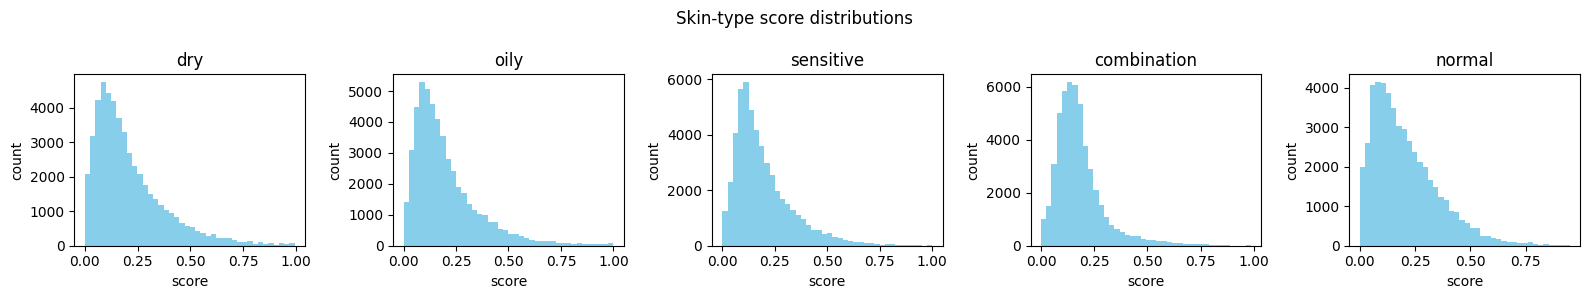

In [38]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
for ax, col in zip(axes, SCORE_COLS):
    ax.hist(df[col], bins=40, color="skyblue", edgecolor="none")
    ax.set_title(col.replace("score_", ""))
    ax.set_xlabel("score")
    ax.set_ylabel("count")
plt.suptitle("Skin-type score distributions")
plt.tight_layout()
plt.show()

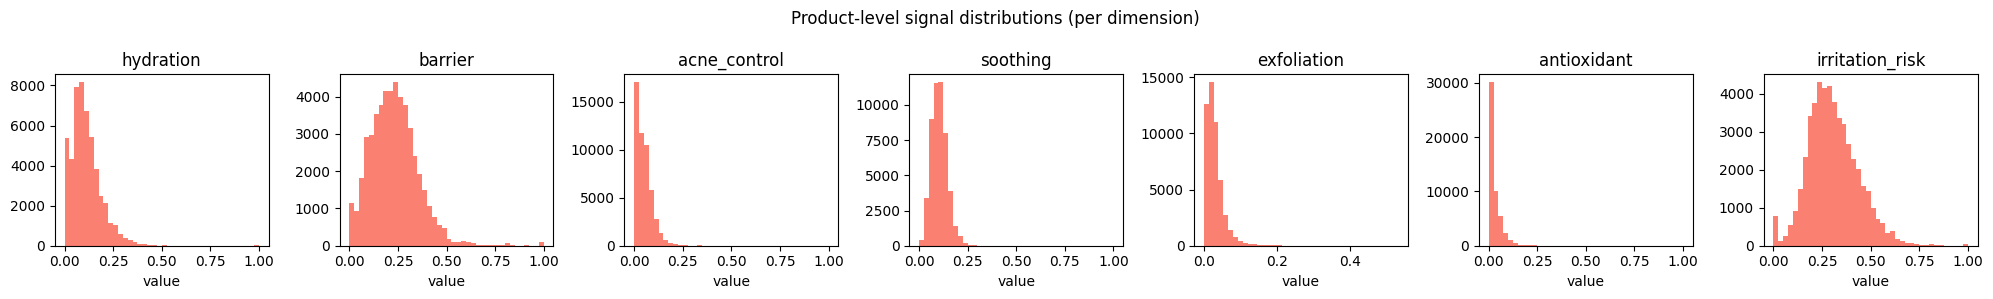

In [39]:
# Signal-level distributions — check for collapse or saturation
fig, axes = plt.subplots(1, len(SIGNAL_KEYS), figsize=(20, 3))
for ax, sig in zip(axes, SIGNAL_KEYS):
    vals = df["signal_vector"].apply(lambda s: s[sig])
    ax.hist(vals, bins=40, color="salmon", edgecolor="none")
    ax.set_title(sig)
    ax.set_xlabel("value")
plt.suptitle("Product-level signal distributions (per dimension)")
plt.tight_layout()
plt.show()

In [40]:
print("Score summary statistics:")
print(df[SCORE_COLS].describe().round(4))
print()

Score summary statistics:
        score_dry  score_oily  score_sensitive  score_combination  \
count  50305.0000  50305.0000       50305.0000         50305.0000   
mean       0.2121      0.2017           0.1961             0.1826   
std        0.1691      0.1597           0.1425             0.1200   
min        0.0000      0.0000           0.0000             0.0000   
25%        0.0912      0.0920           0.0975             0.1073   
50%        0.1647      0.1568           0.1569             0.1578   
75%        0.2851      0.2623           0.2552             0.2214   
max        0.9954      1.0000           1.0000             0.9855   

       score_normal  
count    50305.0000  
mean         0.2075  
std          0.1495  
min          0.0000  
25%          0.0938  
50%          0.1734  
75%          0.2889  
max          0.9488  



In [41]:
# Spot-check: sample products per predicted skin type
name_col = next(
    (c for c in df.columns if "name" in c.lower() or "title" in c.lower()),
    df.columns[0]
)

for st in ["dry", "oily", "sensitive", "combination", "normal"]:
    subset = df[df["skin_type"] == st][[name_col] + SCORE_COLS].head(3)
    print(f"\n── {st.upper()} ──")
    print(subset.to_string(index=False))


── DRY ──
                                                        product_name  score_dry  score_oily  score_sensitive  score_combination  score_normal
          clinique takes the day off cleansing oil, 6.7 fl oz/200 ml   0.766621    0.058016         0.071346           0.063140      0.040878
       necessaire the body lotion, fragrance free, 15.2 fl oz/450 ml   0.420210    0.072161         0.302361           0.075804      0.129464
aestura atobarrier365 moisturizing cream, ceramide, 1.52 fl oz/45 ml   0.728899    0.032955         0.138229           0.057576      0.042342

── OILY ──
                                                            product_name  score_dry  score_oily  score_sensitive  score_combination  score_normal
                  tower 28 sos daily rescue facial spray, 4 fl oz/120 ml   0.000018    0.996462         0.000104           0.001545      0.001871
the ordinary a high-strength serum, alpha arbutin 2% + ha, 1 fl oz/30 ml   0.007567    0.809301         0.011782     

---

## Part 5 — Signal Space Validation

Check that skin-type classes have meaningfully different mean signal profiles, and that between-class separation exceeds within-class spread.

Mean signal vector per skin type:
             hydration  barrier  acne_control  soothing  exfoliation  antioxidant  irritation_risk
skin_type                                                                                         
combination     0.2297   0.1568        0.0556    0.1117       0.0371       0.0294           0.3461
dry             0.0953   0.3674        0.0328    0.0947       0.0251       0.0220           0.3217
normal          0.1037   0.1645        0.0345    0.0876       0.0346       0.0265           0.2337
oily            0.0741   0.1847        0.0935    0.0869       0.0310       0.0276           0.4077
sensitive       0.1031   0.2461        0.0329    0.1535       0.0209       0.0330           0.2424


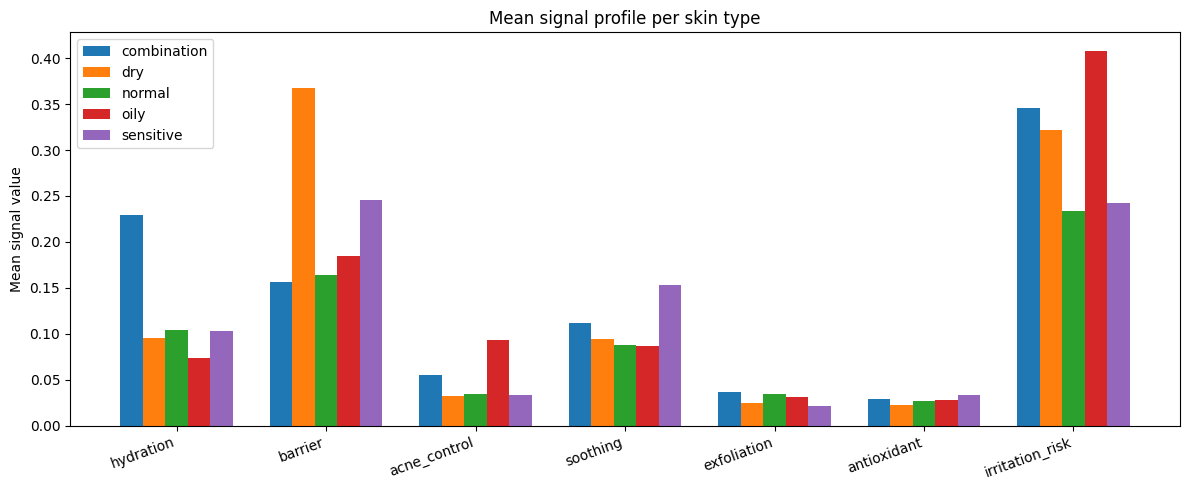

In [42]:
signal_cols_df = pd.json_normalize(df["signal_vector"])
signal_cols_df.index = df.index
signal_cols_df["skin_type"] = df["skin_type"]

class_means = signal_cols_df.groupby("skin_type")[SIGNAL_KEYS].mean().round(4)
print("Mean signal vector per skin type:")
print(class_means.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(SIGNAL_KEYS))
width = 0.15
for i, skin_type in enumerate(class_means.index):
    ax.bar(x + i * width, class_means.loc[skin_type], width, label=skin_type)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(SIGNAL_KEYS, rotation=20, ha='right')
ax.set_ylabel("Mean signal value")
ax.set_title("Mean signal profile per skin type")
ax.legend()
plt.tight_layout()
plt.show()

In [43]:
from itertools import combinations

centroids    = class_means[SIGNAL_KEYS].values
class_labels = list(class_means.index)

print("Between-class centroid distances (Euclidean):")
distances = {}
for (i, a), (j, b) in combinations(enumerate(class_labels), 2):
    d = np.linalg.norm(centroids[i] - centroids[j])
    distances[(a, b)] = d
    print(f"  {a:<15} vs {b:<15}  {d:.4f}")

mean_between = np.mean(list(distances.values()))
within_stds  = signal_cols_df.groupby("skin_type")[SIGNAL_KEYS].std().mean(axis=1)
mean_within  = within_stds.mean()
ratio        = mean_between / mean_within

print(f"\nMean between-class distance : {mean_between:.4f}")
print(f"Mean within-class std       : {mean_within:.4f}")
print(f"Separability ratio          : {ratio:.3f}")
print()
if ratio >= 1.5:
    print("Signal space shows reasonable class separation")
elif ratio >= 0.8:
    print("Moderate overlap")
else:
    print("Heavy overlap")

Between-class centroid distances (Euclidean):
  combination     vs dry              0.2530
  combination     vs normal           0.1721
  combination     vs oily             0.1757
  combination     vs sensitive        0.1931
  dry             vs normal           0.2217
  dry             vs oily             0.2122
  dry             vs sensitive        0.1570
  normal          vs oily             0.1872
  normal          vs sensitive        0.1063
  oily            vs sensitive        0.2004

Mean between-class distance : 0.1879
Mean within-class std       : 0.0567
Separability ratio          : 3.312

✓  Signal space shows reasonable class separation


---

## Part 6 — Export

Flatten signal vectors into columns. Output is an ML-ready dataset where:

```
X = [hydration, barrier, acne_control, soothing, exfoliation, antioxidant, irritation_risk]
y = skin_type  (heuristic label based on ingredient function signals)
```

In [44]:
signal_df = pd.json_normalize(df["signal_vector"])
df = df.drop(columns=[c for c in SIGNAL_KEYS if c in df.columns])
df = df.join(signal_df)

out_path = "../data/processed/products_with_signals.csv"
df.drop(columns=["signal_vector"]).to_csv(out_path, index=False)

print(f"Saved : {out_path}")
print(f"Shape : {df.shape}")
print(f"Columns: {list(df.columns)}")

Saved : ../data/processed/products_with_signals.csv
Shape : (50305, 25)
Columns: ['product_name', 'brand', 'usage_type', 'category', 'ingredients', 'image_url', 'product_url', 'price', 'ingredient_tokens', 'ingredient_tokens_syn', 'ingredient_tokens_clean', 'signal_vector', 'score_dry', 'score_oily', 'score_sensitive', 'score_combination', 'score_normal', 'skin_type', 'hydration', 'barrier', 'acne_control', 'soothing', 'exfoliation', 'antioxidant', 'irritation_risk']
